In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
     ---------------------------------------- 0.2/350.6 MB 6.9 MB/s eta 0:00:51
     ---------------------------------------- 0.5/350.6 MB 8.3 MB/s eta 0:00:43
     ---------------------------------------- 0.7/350.6 MB 6.5 MB/s eta 0:00:54
     ---------------------------------------- 1.3/350.6 MB 7.3 MB/s eta 0:00:49
     ---------------------------------------- 1.6/350.6 MB 7.4 MB/s eta 0:00:47
     ---------------------------------------- 2.0/350.6 MB 7.5 MB/s eta 0:00:47
     ---------------------------------------- 2.3/350.6 MB 7.4 MB/s eta 0:00:47
     ---------------------------------------- 2.7/350.6 MB 7.4 MB/s eta 0:00:48
     ---------------------------------------- 3.0/350.6 MB 7.3 MB/s eta 0:00:48
     ---------------------------------------- 3.3/350.6 MB 7.3 MB/s eta 0:00:48
     ---------------------------------------- 3.7


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [9]:
df = pd.read_csv('diabetes.csv')
display(df.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


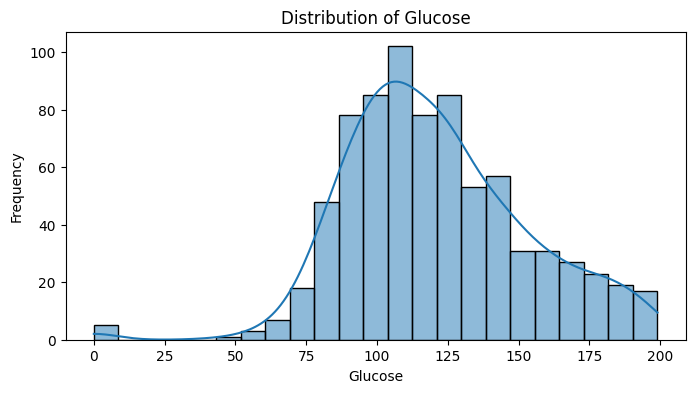

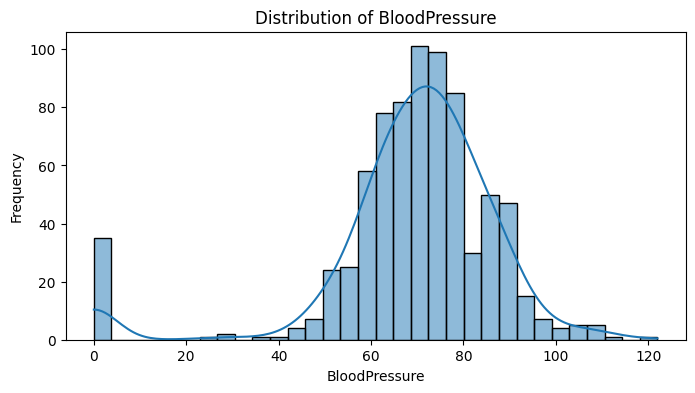

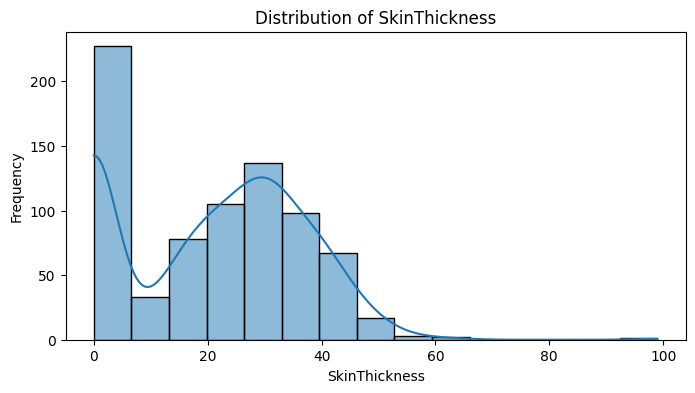

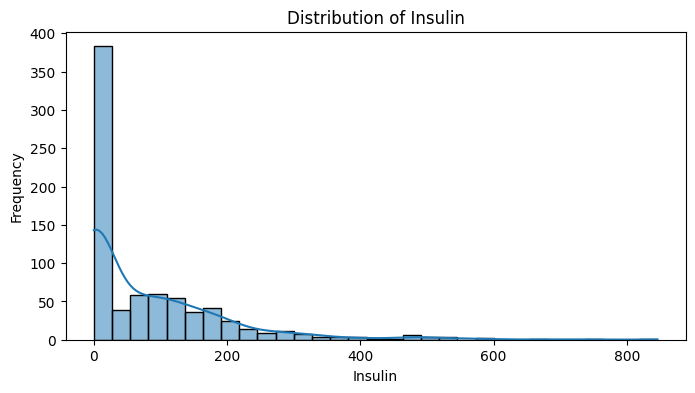

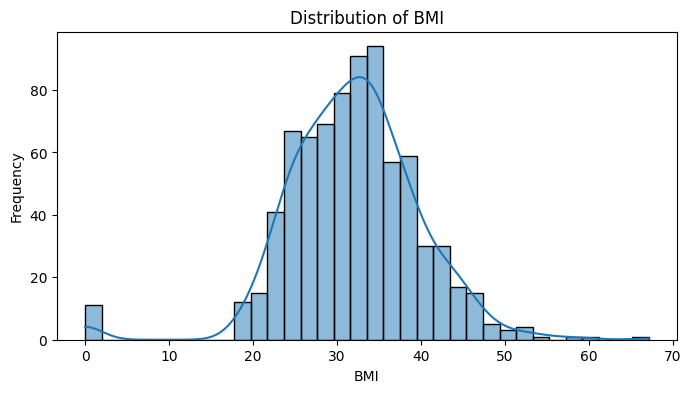

In [10]:
features_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for feature in features_with_zeros:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

In [11]:
df[features_with_zeros] = df[features_with_zeros].replace(0, np.nan)

for feature in features_with_zeros:
    median_val = df[feature].median()
    df[feature].fillna(median_val, inplace=True)

display(df.head())

C:\Users\udhbav_23\AppData\Local\Temp\ipykernel_14080\159119685.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[feature].fillna(median_val, inplace=True)
C:\Users\udhbav_23\AppData\Local\Temp\ipykernel_14080\159119685.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Outcome', axis=1)
y = df['Outcome']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = Sequential()
model.add(Dense(12, input_dim=X_train_scaled.shape[1], activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


model.summary()

C:\Users\udhbav_23\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(X_train_scaled, y_train, epochs=150, batch_size=10, validation_split=0.2)

Epoch 1/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3238 - loss: 0.8938 - val_accuracy: 0.3740 - val_loss: 0.7847
Epoch 2/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4114 - loss: 0.7446 - val_accuracy: 0.5366 - val_loss: 0.6835
Epoch 3/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6640 - loss: 0.6550 - val_accuracy: 0.6748 - val_loss: 0.6172
Epoch 4/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7149 - loss: 0.5949 - val_accuracy: 0.6748 - val_loss: 0.5710
Epoch 5/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7576 - loss: 0.5508 - val_accuracy: 0.7480 - val_loss: 0.5343
Epoch 6/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7678 - loss: 0.5185 - val_accuracy: 0.7480 - val_loss: 0.5096
Epoch 7/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7699 - loss: 0.4971 - val_accuracy: 0.7642 - val_loss: 0.4891
Epoch 8/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7699 - loss: 0.4835 - val_accuracy: 0.7642 - v

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 665 (2.60 KB)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 444 (1.74 KB)

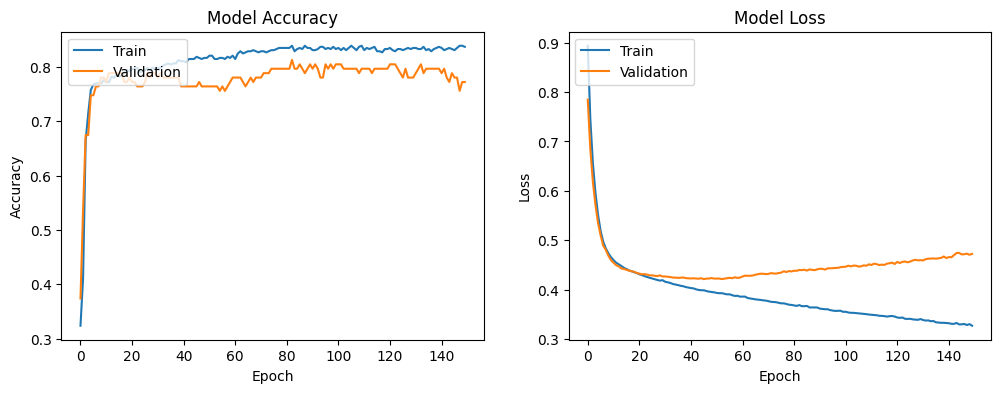

In [14]:
model.summary()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

In [15]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'Test Accuracy: {accuracy:.4f}')
print(f'Test Loss: {loss:.4f}')

Test Accuracy: 0.7013
Test Loss: 0.6633


Epoch 1/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6130 - loss: 0.7306 - val_accuracy: 0.6016 - val_loss: 0.6697
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6314 - loss: 0.6740 - val_accuracy: 0.6260 - val_loss: 0.6233
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6395 - loss: 0.6398 - val_accuracy: 0.6667 - val_loss: 0.5944
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6802 - loss: 0.6127 - val_accuracy: 0.6992 - val_loss: 0.5706
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6741 - loss: 0.5910 - val_accuracy: 0.6829 - val_loss: 0.5535
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6538 - loss: 0.6008 - val_accuracy: 0.6829 - val_loss: 0.5366
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7006 - loss: 0.5787 - val_accuracy: 0.6911 - val_loss: 0.5301
Epoch 8/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6986 - loss: 0.5638 - val_accuracy: 0.6911 - v

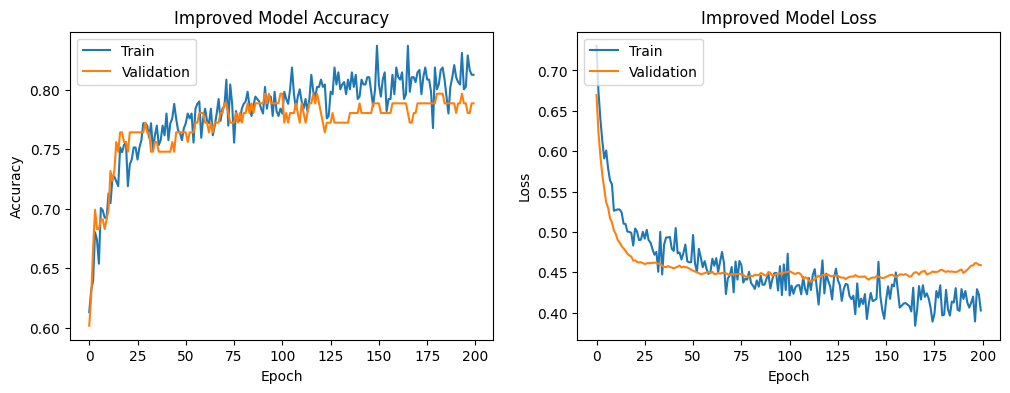

In [16]:
from tensorflow.keras.layers import Dropout

model = Sequential()
model.add(Dense(32, input_dim=X_train_scaled.shape[1], activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history_improved = model.fit(X_train_scaled, y_train, epochs=200, batch_size=10, validation_split=0.2)

loss_improved, accuracy_improved = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'Improved Test Accuracy: {accuracy_improved:.4f}')
print(f'Improved Test Loss: {loss_improved:.4f}')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_improved.history['accuracy'])
plt.plot(history_improved.history['val_accuracy'])
plt.title('Improved Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history_improved.history['loss'])
plt.plot(history_improved.history['val_loss'])
plt.title('Improved Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype("int32")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        99
           1       0.64      0.64      0.64        55

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154


Confusion Matrix:
[[79 20]
 [20 35]]


In [18]:
def predict_with_custom_values(model, scaler, custom_values):
    custom_data = pd.DataFrame([custom_values], columns=X.columns)

    custom_data_scaled = scaler.transform(custom_data)

    prediction_prob = model.predict(custom_data_scaled)
    prediction = (prediction_prob > 0.5).astype("int32")

    if prediction[0] == 1:
        print("\nPrediction: Based on the custom input, the model predicts that the person is likely to have diabetes.")
    else:
        print("\nPrediction: Based on the custom input, the model predicts that the person is unlikely to have diabetes.")

custom_input_values = [3, 180, 85, 45, 250, 40.5, 0.8, 45]

print(f"Using custom input values: {custom_input_values}")
predict_with_custom_values(model, scaler, custom_input_values)

Using custom input values: [3, 180, 85, 45, 250, 40.5, 0.8, 45]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

Prediction: Based on the custom input, the model predicts that the person is likely to have diabetes.


In [21]:
model.save("diabetes_model.keras")
print("Model saved successfully")

Model saved successfully


In [22]:
model.save("diabetes_model.keras")